# Milestone 1 — Merge first: one table, documented

Builds a single occupation-level table (2018 SOC) that joins the three AI job-risk indices:
- **Eloundou et al.** (GPTs are GPTs) — O\*NET-SOC exposure ratings
- **AIOE** (Felten, Raj & Seamans) — 2010 SOC
- **Frey & Osborne** (The Future of Employment) — 2010 SOC

| Task | Description | Status |
|---|---|---|
| 1 | Download all sources | Done (09/11/26) |
| 2 | Roll up Eloundou's codes | Done (09/11/26) |
| 3 | Crosswalk AIOE and Frey-Osborne | Done (09/11/26) |
| 4 | Join all three into one table | Done (09/14/26) |
| 5 | Write coverage report | Done (09/14/26) |
| 6 | Per-index EDA | Done (09/28/26) |
| 7 | Compute percentile ranks | **To-do** (09/28/26) |

## Setup

In [22]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/BTT Fall AI Studio (swytch 1b)'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os
os.makedirs(f'{BASE}/data/raw', exist_ok=True)
os.makedirs(f'{BASE}/data/interim', exist_ok=True)
os.makedirs(f'{BASE}/notebooks', exist_ok=True)

In [24]:
!pip install pdfplumber -q

## Task 1 — Download all sources

All raw inputs live in `data/raw/`:
- `occ_level.csv` — Eloundou et al. occupation-level ratings (O\*NET-SOC)
- `AIOE_DataAppendix.xlsx` — AIOE scores (2010 SOC)
- `The_Future_of_Employment.pdf` — Frey & Osborne; probabilities are parsed from the appendix table
- `soc_2010_to_2018_crosswalk.xlsx` — BLS 2010 SOC ↔ 2018 SOC mapping (includes `#` / `##` split-merge flags)

## Task 2 — Roll up Eloundou's codes

Collapse O\*NET-SOC 8-digit codes (e.g. `11-1011.03`) to 6-digit SOC by averaging each rating column.
Output: `data/interim/eloundou_soc6.csv`

In [25]:
import pandas as pd

RAW_PATH = f'{BASE}/data/raw/occ_level.csv'
OUT_PATH = f'{BASE}/eloundou_soc6.csv'

RATING_COLS = [
    "dv_rating_alpha", "dv_rating_beta", "dv_rating_gamma",
    "human_rating_alpha", "human_rating_beta", "human_rating_gamma",
]

In [26]:
df = pd.read_csv(RAW_PATH)
assert df.shape[0] == 923, f"Expected 923 rows, got {df.shape[0]}"

df['soc6'] = df['O*NET-SOC Code'].str.split('.').str[0]

rolled = (
    df.groupby('soc6')
    .agg(
        **{col: (col, 'mean') for col in RATING_COLS},
        n_children=('O*NET-SOC Code', 'count'),
        child_codes=('O*NET-SOC Code', lambda x: ';'.join(x)),
        child_titles=('Title', lambda x: '; '.join(x)),
    )
    .reset_index()
)

print(f"Rows in: {len(df)} | Rows out: {len(rolled)}")
print(f"Codes rolled up from >1 child: {(rolled['n_children'] > 1).sum()}")
rolled.head()

Rows in: 923 | Rows out: 798
Codes rolled up from >1 child: 67


,soc6,dv_rating_alpha,dv_rating_beta,dv_rating_gamma,human_rating_alpha,human_rating_beta,human_rating_gamma,n_children,child_codes,child_titles
0,11-1011,0.133333,0.507778,0.882222,0.117778,0.369444,0.621111,2,11-1011.00;11-1011.03,Chief Executives; Chief Sustainability Officers
1,11-1021,0.000000,0.480769,0.961538,0.115385,0.384615,0.653846,1,11-1021.00,General and Operations Managers
2,11-1031,0.033333,0.400000,0.766667,0.266667,0.516667,0.766667,1,11-1031.00,Legislators
3,11-2011,0.000000,0.476744,0.953488,0.255814,0.546512,0.837209,1,11-2011.00,Advertising and Promotions Managers
4,11-2021,0.062500,0.500000,0.937500,0.218750,0.578125,0.937500,1,11-2021.00,Marketing Managers


In [27]:
OUT_PATH = f'{BASE}/data/interim/eloundou_soc6.csv'
rolled.to_csv(OUT_PATH, index=False)
print(f"Saved to {OUT_PATH}")

Saved to /content/drive/MyDrive/BTT Fall AI Studio (swytch 1b)/data/interim/eloundou_soc6.csv


## Task 3 — Crosswalk AIOE and Frey-Osborne

Both indices are keyed to 2010 SOC. Map each to 2018 SOC via the BLS crosswalk, averaging where
several 2010 codes merge into one 2018 code, and flag splits/merges. Unmatched codes are logged.

### 3a. AIOE

Outputs: `data/interim/aioe_soc2018.csv`, `data/interim/aioe_coverage_log.csv`

In [28]:
AIOE_PATH = f'{BASE}/data/raw/AIOE_DataAppendix.xlsx'
CROSSWALK_PATH = f'{BASE}/data/raw/soc_2010_to_2018_crosswalk.xlsx'
OUT_PATH = f'{BASE}/data/interim/aioe_soc2018.csv'
COVERAGE_OUT_PATH = f'{BASE}/data/interim/aioe_coverage_log.csv'

In [29]:
aioe = pd.read_excel(AIOE_PATH, sheet_name='Appendix A')
assert aioe.shape[0] == 774, f"Expected 774 AIOE rows, got {aioe.shape[0]}"
aioe = aioe.rename(columns={'SOC Code': 'soc2010', 'Occupation Title': 'title_2010'})

cw = pd.read_excel(CROSSWALK_PATH, sheet_name='Sorted by 2010', skiprows=8)
cw = cw.rename(columns={
    '2010 SOC Code': 'soc2010', '2010 SOC Title': 'title_2010_cw',
    '2018 SOC Code': 'soc2018', '2018 SOC Title': 'title_2018',
})

In [30]:
merged = aioe.merge(cw, on='soc2010', how='left', indicator=True)

no_match = merged[merged['_merge'] == 'left_only'].copy()
no_match['reason'] = 'no_crosswalk_match'

matched = merged[merged['_merge'] == 'both'].copy().drop(columns='_merge')
matched['is_split'] = matched.groupby('soc2010')['soc2018'].transform('nunique') > 1
matched['is_merge'] = matched.groupby('soc2018')['soc2010'].transform('nunique') > 1

rolled = (
    matched.groupby('soc2018')
    .agg(
        AIOE=('AIOE', 'mean'),
        title_2018=('title_2018', 'first'),
        n_2010_parents=('soc2010', 'nunique'),
        parent_soc2010_codes=('soc2010', lambda x: ';'.join(sorted(set(x)))),
        is_split=('is_split', 'any'),
        is_merge=('is_merge', 'any'),
    )
    .reset_index()
)

print(f"Rows out: {len(rolled)} | No match: {len(no_match)} | Split: {rolled['is_split'].sum()} | Merge: {rolled['is_merge'].sum()}")
rolled.head()

Rows out: 800 | No match: 1 | Split: 76 | Merge: 24


,soc2018,AIOE,title_2018,n_2010_parents,parent_soc2010_codes,is_split,is_merge
0,11-1011,1.334246,Chief Executives,1,11-1011,False,False
1,11-1021,0.574877,General and Operations Managers,1,11-1021,False,False
2,11-2011,1.294387,Advertising and Promotions Managers,1,11-2011,False,False
3,11-2021,1.315032,Marketing Managers,1,11-2021,False,False
4,11-2022,1.266280,Sales Managers,1,11-2022,False,False


In [31]:
rolled.to_csv(OUT_PATH, index=False)
no_match.to_csv(COVERAGE_OUT_PATH, index=False)

### 3b. Frey-Osborne

Parse the appendix table from the PDF, then crosswalk.
Outputs: `data/interim/frey_osborne_soc2018.csv`, `data/interim/frey_osborne_coverage_log.csv`

In [32]:
import re
import pdfplumber
import pandas as pd

PDF_PATH = f'{BASE}/data/raw/The_Future_of_Employment.pdf'
CROSSWALK_PATH = f'{BASE}/data/raw/soc_2010_to_2018_crosswalk.xlsx'
APPENDIX_START_PAGE = 56

ROW_PATTERN = re.compile(r"^(\d+)\.\s+([\d.]+)\s+(?:(\d)\s+)?(\d{2}-\d{4})\s+(.+)$")

rows = []
with pdfplumber.open(PDF_PATH) as pdf:
    for i in range(APPENDIX_START_PAGE, len(pdf.pages)):
        text = pdf.pages[i].extract_text() or ""
        for line in text.split("\n"):
            m = ROW_PATTERN.match(line.strip())
            if m:
                rank, prob, label, soc, title = m.groups()
                rows.append({"rank": int(rank), "probability": float(prob),
                             "training_label": label, "soc2010": soc, "title_2010": title})

fo = pd.DataFrame(rows)
assert fo.shape[0] == 702, f"Expected 702 rows, got {fo.shape[0]}"
fo.head()

,rank,probability,training_label,soc2010,title_2010
0,1,0.0028,None,29-1125,RecreationalTherapists
1,2,0.0030,None,49-1011,"First-LineSupervisorsofMechanics,Installers,an..."
2,3,0.0030,None,11-9161,EmergencyManagementDirectors
3,4,0.0031,None,21-1023,MentalHealthandSubstanceAbuseSocialWorkers
4,5,0.0033,None,29-1181,Audiologists


In [33]:
cw = pd.read_excel(CROSSWALK_PATH, sheet_name='Sorted by 2010', skiprows=8)
cw = cw.rename(columns={'2010 SOC Code': 'soc2010', '2010 SOC Title': 'title_2010_cw',
                          '2018 SOC Code': 'soc2018', '2018 SOC Title': 'title_2018'})

merged = fo.merge(cw, on='soc2010', how='left', indicator=True)
no_match = merged[merged['_merge'] == 'left_only'].copy()
no_match['reason'] = 'no_crosswalk_match'

matched = merged[merged['_merge'] == 'both'].copy().drop(columns='_merge')
matched['is_split'] = matched.groupby('soc2010')['soc2018'].transform('nunique') > 1
matched['is_merge'] = matched.groupby('soc2018')['soc2010'].transform('nunique') > 1

rolled = (
    matched.groupby('soc2018')
    .agg(probability=('probability', 'mean'), title_2018=('title_2018', 'first'),
         n_2010_parents=('soc2010', 'nunique'),
         parent_soc2010_codes=('soc2010', lambda x: ';'.join(sorted(set(x)))),
         is_split=('is_split', 'any'), is_merge=('is_merge', 'any'))
    .reset_index()
)

print(f"Rows out: {len(rolled)} | No match: {len(no_match)} | Split: {rolled['is_split'].sum()} | Merge: {rolled['is_merge'].sum()}")

Rows out: 699 | No match: 17 | Split: 48 | Merge: 16


In [34]:
rolled.to_csv(f'{BASE}/data/interim/frey_osborne_soc2018.csv', index=False)
no_match.to_csv(f'{BASE}/data/interim/frey_osborne_coverage_log.csv', index=False)

## Task 4 — Join all three into one table

Outer-join the three interim tables on 2018 SOC and keep occupations scored by all three indices.
Output: `data/processed/merged_ai_risk_v0.csv`

In [35]:
elo = pd.read_csv(f'{BASE}/data/interim/eloundou_soc6.csv').rename(columns={'soc6': 'soc'})
aioe = pd.read_csv(f'{BASE}/data/interim/aioe_soc2018.csv').rename(columns={
    'soc2018': 'soc', 'title_2018': 'title_aioe',
    'n_2010_parents': 'aioe_n_2010_parents', 'parent_soc2010_codes': 'aioe_parent_soc2010_codes',
    'is_split': 'aioe_is_split', 'is_merge': 'aioe_is_merge'})
fo = pd.read_csv(f'{BASE}/data/interim/frey_osborne_soc2018.csv').rename(columns={
    'soc2018': 'soc', 'title_2018': 'title_frey_osborne',
    'n_2010_parents': 'fo_n_2010_parents', 'parent_soc2010_codes': 'fo_parent_soc2010_codes',
    'is_split': 'fo_is_split', 'is_merge': 'fo_is_merge'})

m = elo.merge(aioe, on='soc', how='outer', indicator='in_aioe')
m = m.merge(fo, on='soc', how='outer', indicator='in_fo')

m['has_eloundou'] = m['dv_rating_alpha'].notna()
m['has_aioe'] = m['AIOE'].notna()
m['has_frey_osborne'] = m['probability'].notna()
m['n_sources'] = m[['has_eloundou', 'has_aioe', 'has_frey_osborne']].sum(axis=1)

final = m[m['n_sources'] == 3].copy().drop(columns=['in_aioe', 'in_fo'])

print(f"Final table: {len(final)}")

import os
os.makedirs(f'{BASE}/data/processed', exist_ok=True)
final.to_csv(f'{BASE}/data/processed/merged_ai_risk_v0.csv', index=False)

Final table: 693


## Task 5 — Write coverage report

Every occupation dropped from the final table, with the reason (which index is missing it).
Output: `data/processed/coverage_report_v0.csv`

Crosswalk-level drops (2010 codes with no 2018 match) are in the Task 3 coverage logs.

In [36]:
dropped = m[m['n_sources'] < 3].copy()

def reason(row):
    missing = [s for s, has in [('eloundou', row['has_eloundou']),
                                  ('aioe', row['has_aioe']),
                                  ('frey_osborne', row['has_frey_osborne'])] if not has]
    return 'missing_from_' + '_and_'.join(missing)

dropped['reason'] = dropped.apply(reason, axis=1)
dropped = dropped[['soc', 'has_eloundou', 'has_aioe', 'has_frey_osborne', 'reason']]

print(f"Dropped: {len(dropped)}")
print(dropped['reason'].value_counts())

dropped.to_csv(f'{BASE}/data/processed/coverage_report_v0.csv', index=False)

Dropped: 115
reason
missing_from_frey_osborne                 97
missing_from_aioe_and_frey_osborne         8
missing_from_eloundou                      6
missing_from_eloundou_and_frey_osborne     4
Name: count, dtype: int64


## Task 6 — Per-index EDA

### 6a. Eloundou: rating distributions and GPT-4 vs. human agreement

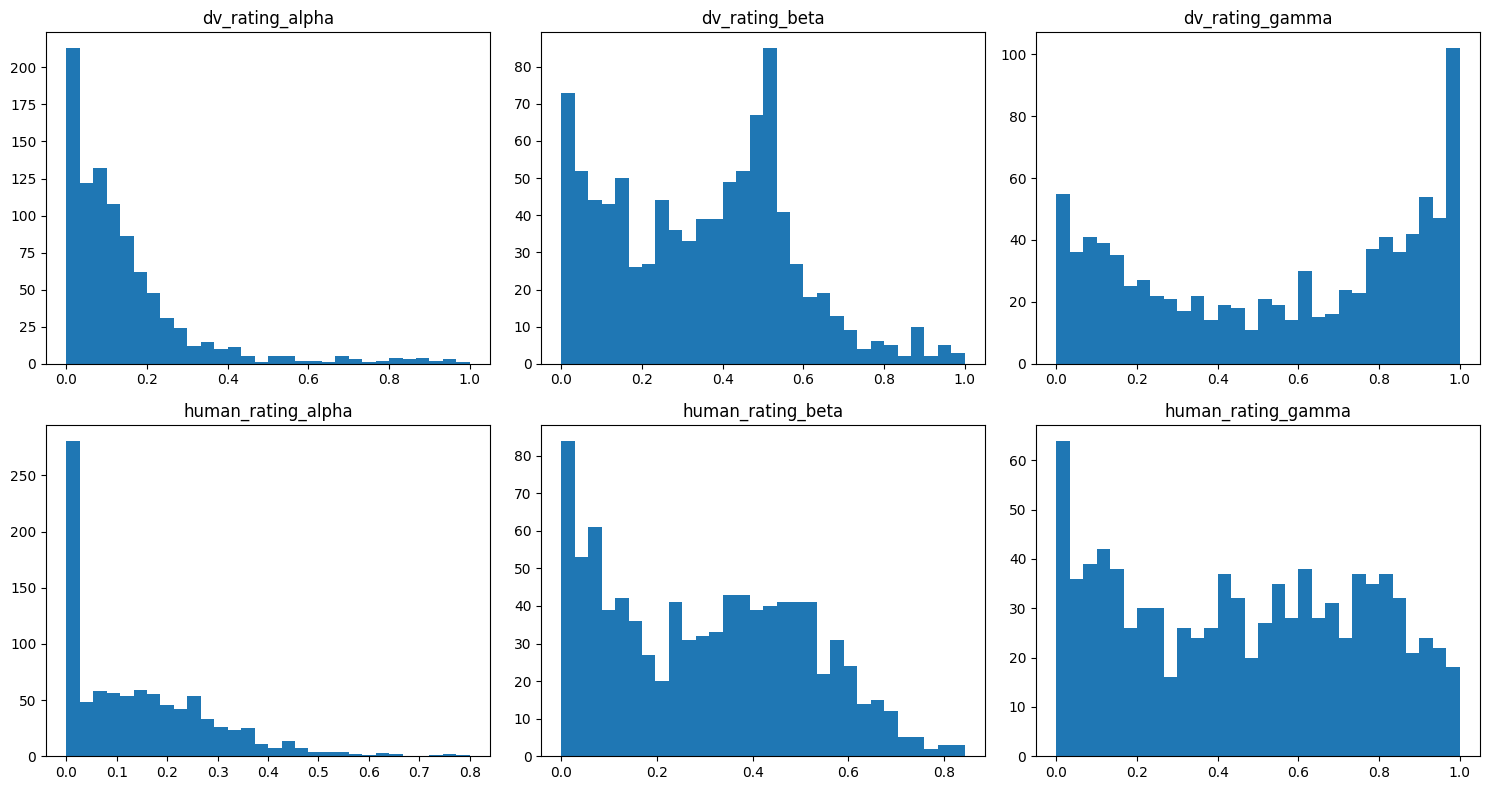

In [37]:
import matplotlib.pyplot as plt

cols = ['dv_rating_alpha', 'dv_rating_beta', 'dv_rating_gamma',
        'human_rating_alpha', 'human_rating_beta', 'human_rating_gamma']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cols):
    ax.hist(df[col], bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [38]:
pairs = [('alpha', 'dv_rating_alpha', 'human_rating_alpha'),
         ('beta', 'dv_rating_beta', 'human_rating_beta'),
         ('gamma', 'dv_rating_gamma', 'human_rating_gamma')]

for label, dv_col, human_col in pairs:
    corr = df[[dv_col, human_col]].corr(method='spearman').iloc[0, 1]
    print(f"{label}: Spearman(GPT-4, human) = {corr:.3f}")

alpha: Spearman(GPT-4, human) = 0.455
beta: Spearman(GPT-4, human) = 0.901
gamma: Spearman(GPT-4, human) = 0.915


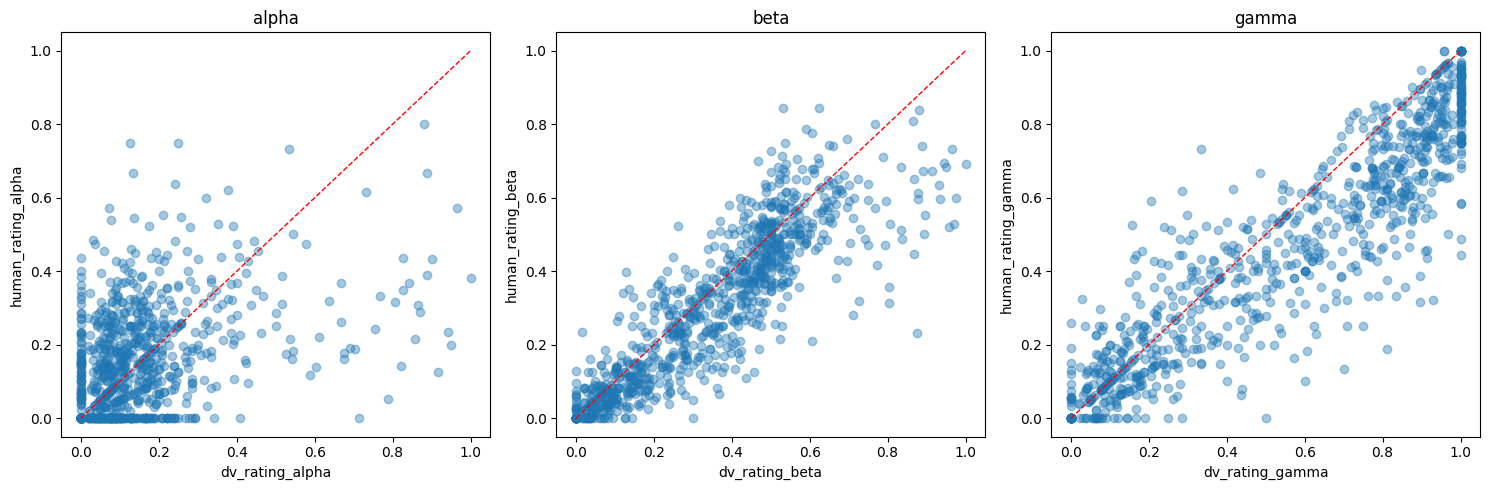

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, dv_col, human_col) in zip(axes, pairs):
    ax.scatter(df[dv_col], df[human_col], alpha=0.4)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
    ax.set_xlabel(dv_col)
    ax.set_ylabel(human_col)
    ax.set_title(label)
plt.tight_layout()
plt.show()

In [40]:
df[cols].corr(method='spearman')

,dv_rating_alpha,dv_rating_beta,dv_rating_gamma,human_rating_alpha,human_rating_beta,human_rating_gamma
dv_rating_alpha,1.000000,0.637281,0.448791,0.454679,0.513809,0.494879
dv_rating_beta,0.637281,1.000000,0.963403,0.745128,0.900684,0.908348
dv_rating_gamma,0.448791,0.963403,1.000000,0.728332,0.897925,0.915422
human_rating_alpha,0.454679,0.745128,0.728332,1.000000,0.887704,0.781098
human_rating_beta,0.513809,0.900684,0.897925,0.887704,1.000000,0.977593
human_rating_gamma,0.494879,0.908348,0.915422,0.781098,0.977593,1.000000


### 6b. AIOE (raw appendix, crosswalked table, coverage log)

Files covered: `data/raw/AIOE_DataAppendix.xlsx`, `data/interim/aioe_soc2018.csv`,
`data/interim/aioe_coverage_log.csv`, plus how AIOE survives the join into `merged_ai_risk_v0.csv`.

#### 1. Raw file: sheets and integrity checks
Only Appendix A (occupation scores) feeds the pipeline; the other sheets are industry, county and
ability-level versions of the same measure.

In [41]:
aioe_xl = pd.ExcelFile(f'{BASE}/data/raw/AIOE_DataAppendix.xlsx')
for sheet in aioe_xl.sheet_names:
    print(f"{sheet:<12} {aioe_xl.parse(sheet).shape}")

aioe_raw = aioe_xl.parse('Appendix A').rename(
    columns={'SOC Code': 'soc2010', 'Occupation Title': 'title_2010'})
aioe_raw['major_group'] = aioe_raw['soc2010'].str[:2]

print("\nnulls:", aioe_raw.isna().sum().to_dict())
print("duplicate codes:", aioe_raw['soc2010'].duplicated().sum())
print("duplicate titles:", aioe_raw['title_2010'].duplicated().sum())
print("badly formatted codes:", (~aioe_raw['soc2010'].str.match(r'^\d{2}-\d{4}$')).sum())
# Detailed SOC codes never end in 0; a trailing 0 means a broad (aggregate) code
print("broad codes:", aioe_raw.loc[aioe_raw['soc2010'].str.endswith('0'), ['soc2010', 'title_2010']].values.tolist())

Index        (4, 1)
Appendix A   (774, 3)
Appendix B   (250, 3)
Appendix C   (3271, 3)
Appendix D   (52, 11)
Appendix E   (52, 2)

nulls: {'soc2010': 0, 'title_2010': 0, 'AIOE': 0, 'major_group': 0}
duplicate codes: 0
duplicate titles: 0
badly formatted codes: 0
broad codes: [['19-1020', 'Biologists']]


#### 2. Raw file: distribution and outliers
AIOE is a standardized score (mean 0, sd 1), so values are relative exposure, not a probability.

count    7.740000e+02
mean    -6.847545e-09
std      1.000000e+00
min     -2.669758e+00
25%     -8.645451e-01
50%     -5.119285e-02
75%      1.014434e+00
max      1.527667e+00
Name: AIOE, dtype: float64
skew: -0.067 | excess kurtosis: -1.269
IQR (1.5x) outliers: 0


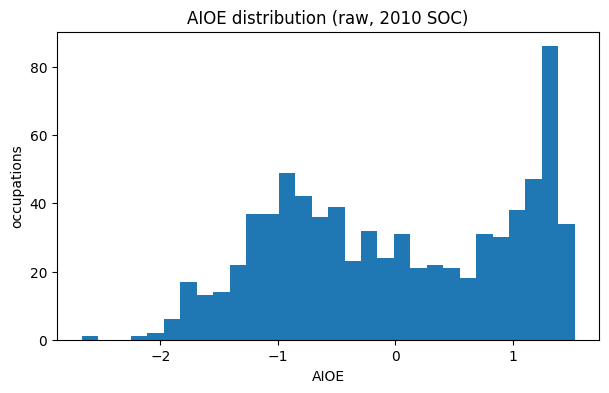

In [42]:
print(aioe_raw['AIOE'].describe())
print(f"skew: {aioe_raw['AIOE'].skew():.3f} | excess kurtosis: {aioe_raw['AIOE'].kurt():.3f}")

q1, q3 = aioe_raw['AIOE'].quantile([0.25, 0.75])
iqr = q3 - q1
iqr_out = aioe_raw[(aioe_raw['AIOE'] < q1 - 1.5 * iqr) | (aioe_raw['AIOE'] > q3 + 1.5 * iqr)]
print(f"IQR (1.5x) outliers: {len(iqr_out)}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(aioe_raw['AIOE'], bins=30)
ax.set_xlabel('AIOE')
ax.set_ylabel('occupations')
ax.set_title('AIOE distribution (raw, 2010 SOC)')
plt.show()

In [43]:
show = ['soc2010', 'title_2010', 'AIOE']
print("Most exposed:")
print(aioe_raw.nlargest(10, 'AIOE')[show].to_string(index=False))
print("\nLeast exposed:")
print(aioe_raw.nsmallest(10, 'AIOE')[show].to_string(index=False))

Most exposed:
soc2010                                                     title_2010     AIOE
29-9092                                             Genetic Counselors 1.527667
13-2061                                            Financial Examiners 1.526064
15-2011                                                      Actuaries 1.516474
13-1023 Purchasing Agents, Except Wholesale, Retail, and Farm Products 1.509181
13-2031                                                Budget Analysts 1.502988
23-1023                     Judges, Magistrate Judges, and Magistrates 1.496494
43-3061                                             Procurement Clerks 1.487838
13-2011                                       Accountants and Auditors 1.481956
15-2021                                                 Mathematicians 1.472319
23-1012                                            Judicial Law Clerks 1.462973

Least exposed:
soc2010                                                                  title_2010      A

             count  mean  median   std
major_group                           
47              57 -1.34   -1.40  0.45
37               8 -1.15   -1.16  0.52
45              13 -1.06   -1.11  0.53
51             103 -0.83   -0.90  0.45
49              51 -0.88   -0.89  0.37
53              48 -0.74   -0.80  0.57
35              16 -0.77   -0.67  0.50
31              17 -0.51   -0.53  0.63
33              21 -0.36   -0.51  0.50
39              30 -0.29   -0.36  0.66
29              59  0.19    0.10  0.51
27              36  0.27    0.62  0.95
41              21  0.64    0.89  0.69
17              34  0.81    0.94  0.46
21              14  0.88    0.95  0.39
43              52  0.65    1.00  0.78
19              43  0.83    1.01  0.56
11              33  0.96    1.05  0.43
15              18  1.11    1.22  0.33
25              60  0.99    1.22  0.47
13              32  1.17    1.34  0.41
23               8  1.31    1.35  0.21


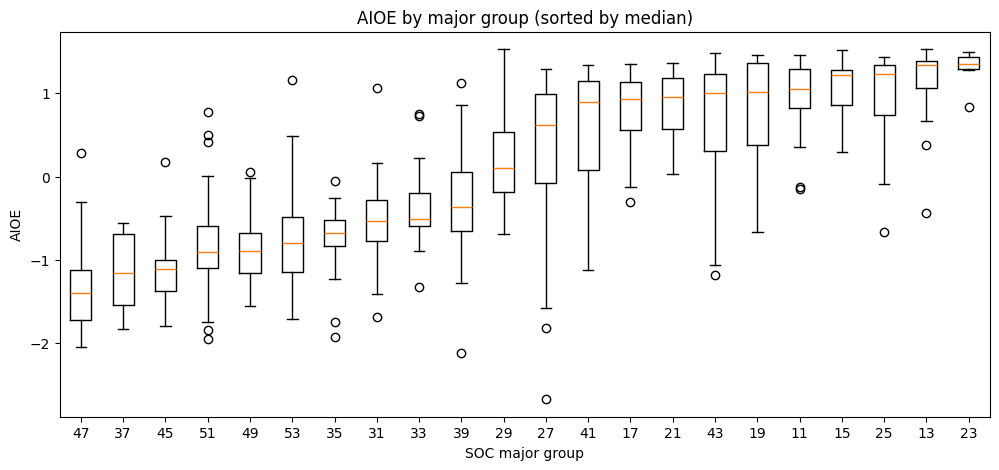

In [44]:
by_mg = (aioe_raw.groupby('major_group')['AIOE']
         .agg(['count', 'mean', 'median', 'std']).sort_values('median').round(2))
print(by_mg)

order = by_mg.index
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot([aioe_raw.loc[aioe_raw['major_group'] == g, 'AIOE'] for g in order])
ax.set_xticks(range(1, len(order) + 1), order)
ax.set_xlabel('SOC major group')
ax.set_ylabel('AIOE')
ax.set_title('AIOE by major group (sorted by median)')
plt.show()

#### 3. Coverage against the SOC crosswalk and the coverage log

In [45]:
cw_eda = pd.read_excel(f'{BASE}/data/raw/soc_2010_to_2018_crosswalk.xlsx',
                       sheet_name='Sorted by 2010', skiprows=8)
cw_eda = cw_eda.rename(columns={'2010 SOC Code': 'soc2010', '2010 SOC Title': 'title_2010_cw',
                                '2018 SOC Code': 'soc2018', '2018 SOC Title': 'title_2018'})

cw10 = set(cw_eda['soc2010'])
print(f"crosswalk 2010 codes: {len(cw10)} | scored by AIOE: {len(cw10 & set(aioe_raw['soc2010']))}"
      f" | not scored: {len(cw10 - set(aioe_raw['soc2010']))}")

aioe_log = pd.read_csv(f'{BASE}/data/interim/aioe_coverage_log.csv')
print(f"\nAIOE codes with no crosswalk match: {len(aioe_log)}")
print(aioe_log[['soc2010', 'title_2010', 'AIOE', 'reason']].to_string(index=False))

# The unmatched code is broad; show the detailed crosswalk codes it covers
broad = aioe_log['soc2010'].str[:6].unique()
print(cw_eda[cw_eda['soc2010'].str[:6].isin(broad)][['soc2010', 'title_2010_cw', 'soc2018']].to_string(index=False))

crosswalk 2010 codes: 840 | scored by AIOE: 773 | not scored: 67

AIOE codes with no crosswalk match: 1
soc2010 title_2010     AIOE             reason
19-1020 Biologists 0.752081 no_crosswalk_match
soc2010                      title_2010_cw soc2018
19-1021      Biochemists and Biophysicists 19-1021
19-1022                    Microbiologists 19-1022
19-1023 Zoologists and Wildlife Biologists 19-1023
19-1029   Biological Scientists, All Other 19-1029


In [46]:
# 2010 occupations AIOE never scored, by major group
unscored = cw_eda[~cw_eda['soc2010'].isin(aioe_raw['soc2010'])].drop_duplicates('soc2010')
print(unscored['soc2010'].str[:2].value_counts().to_string())
unscored[['soc2010', 'title_2010_cw']].head(20)

soc2010
55    20
27     5
51     5
43     4
21     4
53     4
25     3
39     3
47     3
29     2
45     2
35     2
37     2
19     1
17     1
15     1
11     1
33     1
23     1
41     1
49     1


,soc2010,title_2010_cw
2,11-1031,Legislators
101,15-2099,"Mathematical Science Occupations, All Other (#)"
128,17-3019,"Drafters, All Other"
150,19-1099,"Life Scientists, All Other"
191,21-1019,"Counselors, All Other"
195,21-1029,"Social Workers, All Other"
200,21-1099,"Community and Social Service Specialists, All ..."
203,21-2099,"Religious Workers, All Other"
212,23-2099,"Legal Support Workers, All Other"
232,25-1069,"Social Sciences Teachers, Postsecondary, All O..."


#### 4. Crosswalked table (`aioe_soc2018.csv`): what the 2010 → 2018 mapping did
Splits copy a parent's score to every child; merges average the parents.

rows: raw 774 -> crosswalked 800
split children: 76 | merged codes: 24
2010 parents per 2018 code: {1: 776, 2: 22, 3: 2}
           raw  crosswalked
count  774.000      800.000
mean    -0.000        0.028
std      1.000        0.991
min     -2.670       -2.670
25%     -0.865       -0.837
50%     -0.051        0.035
75%      1.014        1.011
max      1.528        1.528


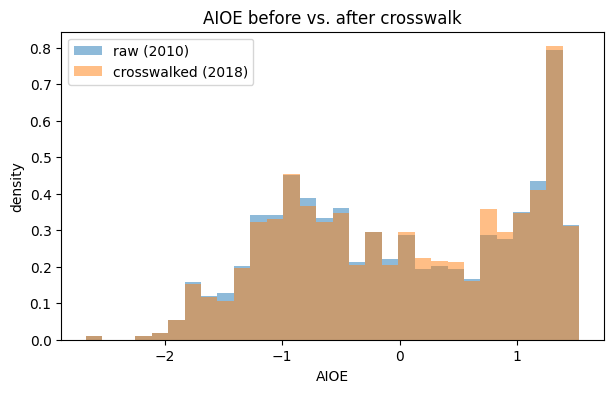

In [47]:
aioe_x = pd.read_csv(f'{BASE}/data/interim/aioe_soc2018.csv')
print(f"rows: raw {len(aioe_raw)} -> crosswalked {len(aioe_x)}")
print(f"split children: {aioe_x['is_split'].sum()} | merged codes: {aioe_x['is_merge'].sum()}")
print("2010 parents per 2018 code:", aioe_x['n_2010_parents'].value_counts().sort_index().to_dict())

print(pd.DataFrame({'raw': aioe_raw['AIOE'].describe(), 'crosswalked': aioe_x['AIOE'].describe()}).round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(aioe_raw['AIOE'], bins=30, alpha=0.5, density=True, label='raw (2010)')
ax.hist(aioe_x['AIOE'], bins=30, alpha=0.5, density=True, label='crosswalked (2018)')
ax.set_xlabel('AIOE')
ax.set_ylabel('density')
ax.legend()
ax.set_title('AIOE before vs. after crosswalk')
plt.show()

In [48]:
# Merge conflicts: 2018 codes whose 2010 parents disagree on AIOE.
# The pipeline averages them, so a wide range means the 2018 score describes neither parent well.
pm = cw_eda.merge(aioe_raw[['soc2010', 'AIOE']], on='soc2010')
spread = pm.groupby(['soc2018', 'title_2018'])['AIOE'].agg(['count', 'min', 'max'])
spread = spread[spread['count'] > 1].assign(range=lambda d: d['max'] - d['min'])
print(f"merged 2018 codes: {len(spread)} | parent range > 0.5 sd: {(spread['range'] > 0.5).sum()}")
spread.sort_values('range', ascending=False).head(10).round(2)

merged 2018 codes: 24 | parent range > 0.5 sd: 6


,,count,min,max,range
soc2018,title_2018,,,,
51-9162,Computer Numerically Controlled Tool Programmers (##),2,-1.29,-0.02,1.27
39-1013,First-line Supervisors of Gambling Services Workers (##),2,-0.14,1.13,1.27
49-9099,"Installation, Maintenance, and Repair Workers, All Other (##)",2,-1.37,-0.59,0.78
51-9161,Computer Numerically Controlled Tool Operators (##),2,-1.29,-0.67,0.62
25-4022,Librarians and Media Collections Specialists (##),2,0.45,1.04,0.59
15-1299,"Computer Occupations, All Other (##)",2,0.70,1.23,0.53
53-4022,"Railroad Brake, Signal, and Switch Operators and Locomotive Firers (##)",2,-1.22,-0.77,0.45
19-4044,Hydrologic Technicians (##),2,0.08,0.45,0.37
29-9021,Health Information Technologists and Medical Registrars (##),2,0.23,0.57,0.34


#### 5. AIOE after the three-way join
Does keeping only occupations scored by all three indices bias the AIOE distribution?

in_final
kept       693
dropped    107
          count   mean    std    min    25%    50%    75%    max
in_final                                                        
False     107.0  0.576  0.808 -1.679  0.154  0.709  1.307  1.528
True      693.0 -0.057  0.990 -2.670 -0.885 -0.182  0.923  1.526

Dropped AIOE occupations by major group:
soc2018
25    44
29    30
15     6
31     4
33     3
47     3
13     3
45     3
11     2
53     2


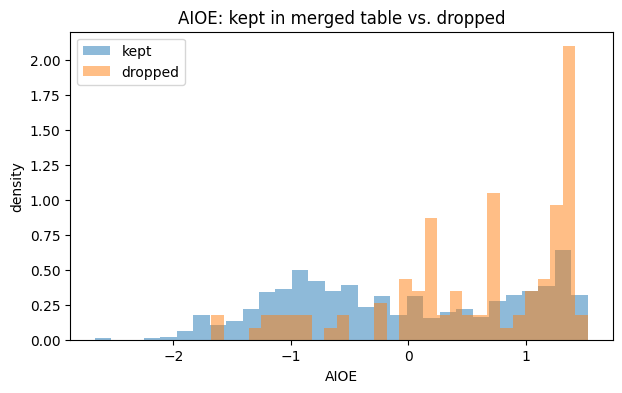

In [49]:
aioe_x['in_final'] = aioe_x['soc2018'].isin(final['soc'])
print(aioe_x['in_final'].value_counts().rename({True: 'kept', False: 'dropped'}).to_string())
print(aioe_x.groupby('in_final')['AIOE'].describe().round(3))

dropped_aioe = aioe_x[~aioe_x['in_final']]
print("\nDropped AIOE occupations by major group:")
print(dropped_aioe['soc2018'].str[:2].value_counts().head(10).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(aioe_x.loc[aioe_x['in_final'], 'AIOE'], bins=30, alpha=0.5, density=True, label='kept')
ax.hist(dropped_aioe['AIOE'], bins=30, alpha=0.5, density=True, label='dropped')
ax.set_xlabel('AIOE')
ax.set_ylabel('density')
ax.legend()
ax.set_title('AIOE: kept in merged table vs. dropped')
plt.show()

### 6d. Cross-index: AIOE vs. Frey-Osborne (merged table)

In [50]:
print(final[['AIOE', 'probability']].corr(method='spearman'))

                 AIOE  probability
AIOE         1.000000    -0.363438
probability -0.363438     1.000000


## Task 7 — Compute percentile ranks

**To-do.** Convert each index to a 0–100 percentile rank within the merged table so they are on a
common scale for comparison.